# Contrastive Divergence
## Derivation from KL Divergence, Energy-Based Models, and Quantum Boltzmann Machines
**Morten Hjorth-Jensen** — April 30, 2026

---

### Overview
These notes derive contrastive divergence (CD) from the Kullback–Leibler divergence
and connect it to:
1. classical Boltzmann machines (BMs),
2. general energy-based models (EBMs),
3. restricted Boltzmann machines (RBMs),
4. quantum Boltzmann machines (QBMs).

**The central question:**
$$\boxed{\text{Why is the approximate Boltzmann-machine gradient called }\textit{contrastive divergence}?}$$


## Setup and Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm, bernoulli
from scipy.special import rel_entr   # element-wise KL: p*log(p/q)

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})
COLORS = plt.rcParams['axes.prop_cycle'].by_key()['color']
import matplotlib; print('NumPy', np.__version__, '| Matplotlib', matplotlib.__version__)


NumPy 1.22.3 | Matplotlib 3.8.4


---
## 1  The KL Divergence

### 1.1  Definition and learning problem

Let $p_{\mathrm{data}}(x)$ be the data distribution and $p_\theta(x)$ a parametric model.
**Maximum likelihood** (ML) maximises the expected log-likelihood:

$$\mathcal{L}(\theta) = \mathbb{E}_{p_{\mathrm{data}}}[\log p_\theta(x)].$$

This is equivalent to minimising the **Kullback–Leibler divergence**:

$$D_{\mathrm{KL}}(p_{\mathrm{data}}\,\|\,p_\theta)
= \sum_x p_{\mathrm{data}}(x)\log\frac{p_{\mathrm{data}}(x)}{p_\theta(x)}
= \underbrace{H(p_{\mathrm{data}})}_{\text{const.}} - \mathcal{L}(\theta).$$

Since $H(p_{\mathrm{data}})$ does not depend on $\theta$, minimising
$D_{\mathrm{KL}}(p_{\mathrm{data}}\|p_\theta)$ and maximising $\mathcal{L}(\theta)$ are
exactly the same optimisation problem.

### 1.2  Key properties

- **Non-negativity:** $D_{\mathrm{KL}}(p\|q)\ge 0$, with equality iff $p=q$.
  *Proof (Jensen's inequality):* since $-\log$ is convex,
  $$D_{\mathrm{KL}}(p\|q)
    = \mathbb{E}_p\!\left[-\log\frac{q(x)}{p(x)}\right]
    \ge -\log\mathbb{E}_p\!\left[\frac{q(x)}{p(x)}\right]
    = -\log\sum_x q(x) = 0.$$
- **Asymmetry:** $D_{\mathrm{KL}}(p\|q)\ne D_{\mathrm{KL}}(q\|p)$ in general.
- **Mode-covering:** $D_{\mathrm{KL}}(p\|q)$ penalises regions where $p>0$ but
  $q\approx 0$ — ML estimation "covers" all modes of $p_{\mathrm{data}}$.


### 1.3  Code: KL divergence for discrete distributions

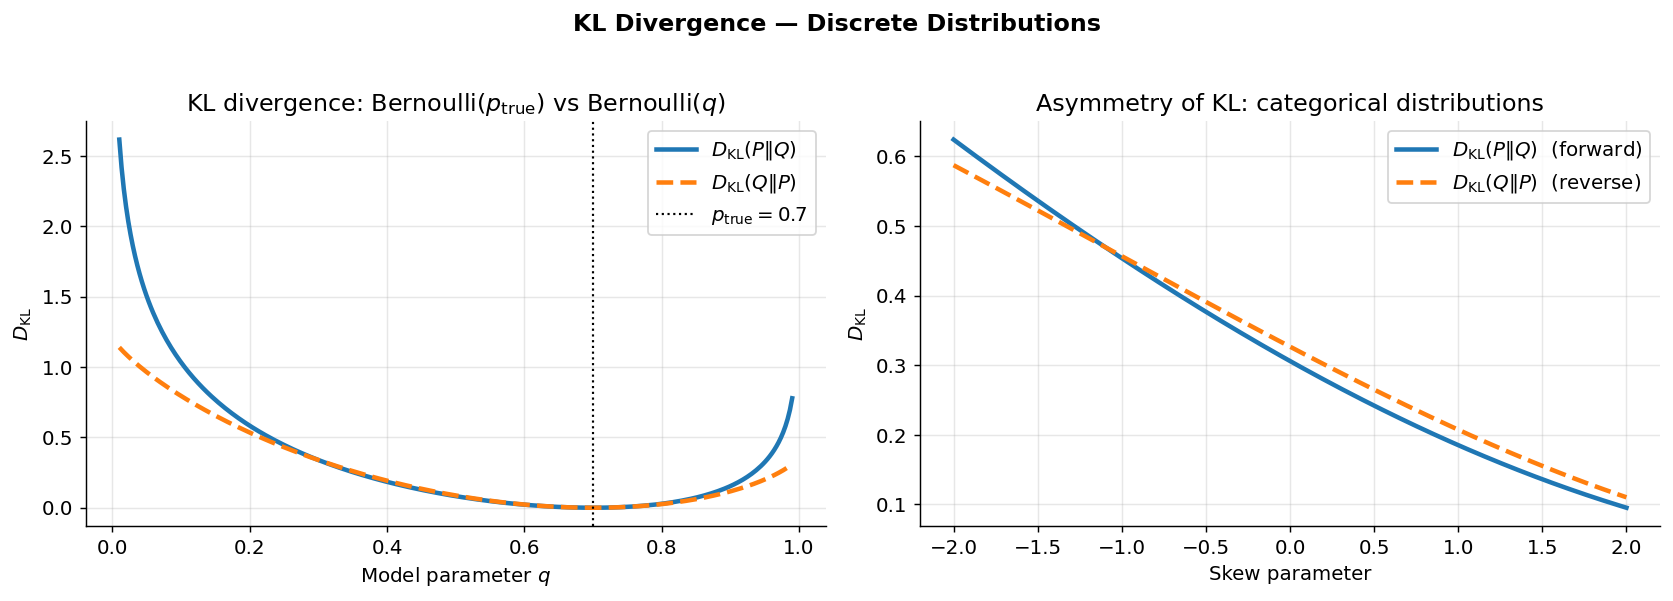

KL(P||Q) at q=p_true=0.7:  -0.000000  (should be 0)
KL(P||Q) at q=0.3:              0.3389
KL(Q||P) at q=0.3:              0.3389  (different!)


In [2]:
def kl_discrete(p, q, eps=1e-12):
    """KL(p||q) for two discrete probability vectors, clipped for numerical stability."""
    p, q = np.asarray(p, float), np.asarray(q, float)
    p, q = p / p.sum(), q / q.sum()          # normalise
    mask = p > eps
    return float(np.sum(p[mask] * np.log(p[mask] / (q[mask] + eps))))

def kl_symmetric(p, q):
    """Jensen-Shannon-related symmetric measure: 0.5*[KL(p||q) + KL(q||p)]."""
    return 0.5 * (kl_discrete(p, q) + kl_discrete(q, p))

# ── Example 1: two Bernoulli distributions ─────────────────────────────────
# P = Bernoulli(p_true), Q = Bernoulli(q)
p_true = 0.7
q_vals = np.linspace(0.01, 0.99, 300)

kl_pq = [kl_discrete([1-p_true, p_true], [1-q, q]) for q in q_vals]
kl_qp = [kl_discrete([1-q, q], [1-p_true, p_true]) for q in q_vals]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(q_vals, kl_pq, lw=2.5, label=r'$D_{\mathrm{KL}}(P\|Q)$', color=COLORS[0])
axes[0].plot(q_vals, kl_qp, lw=2.5, label=r'$D_{\mathrm{KL}}(Q\|P)$', color=COLORS[1], ls='--')
axes[0].axvline(p_true, color='k', lw=1.2, ls=':', label=f'$p_{{\\mathrm{{true}}}}={p_true}$')
axes[0].set_xlabel(r'Model parameter $q$')
axes[0].set_ylabel(r'$D_{\mathrm{KL}}$')
axes[0].set_title(r'KL divergence: Bernoulli($p_{\mathrm{true}}$) vs Bernoulli($q$)')
axes[0].legend()

# ── Example 2: asymmetry visualised ────────────────────────────────────────
# Fix p_true and vary skewness of Q (categorical, 5 classes)
probs_P = np.array([0.05, 0.10, 0.50, 0.25, 0.10])   # bimodal
skew    = np.linspace(-2, 2, 200)
probs_Q = [np.exp(probs_P * s) for s in skew]
probs_Q = [q / q.sum() for q in probs_Q]

kl_fw = [kl_discrete(probs_P, q) for q in probs_Q]
kl_rv = [kl_discrete(q, probs_P) for q in probs_Q]

axes[1].plot(skew, kl_fw, lw=2.5, label=r'$D_{\mathrm{KL}}(P\|Q)$  (forward)', color=COLORS[0])
axes[1].plot(skew, kl_rv, lw=2.5, label=r'$D_{\mathrm{KL}}(Q\|P)$  (reverse)', color=COLORS[1], ls='--')
axes[1].set_xlabel('Skew parameter')
axes[1].set_ylabel(r'$D_{\mathrm{KL}}$')
axes[1].set_title('Asymmetry of KL: categorical distributions')
axes[1].legend()

plt.suptitle('KL Divergence — Discrete Distributions', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'KL(P||Q) at q=p_true={p_true}:  {kl_discrete([1-p_true, p_true],[1-p_true, p_true]):.6f}  (should be 0)')
print(f'KL(P||Q) at q=0.3:              {kl_discrete([1-p_true, p_true],[0.7, 0.3]):.4f}')
print(f'KL(Q||P) at q=0.3:              {kl_discrete([0.7, 0.3],[1-p_true, p_true]):.4f}  (different!)')


### 1.4  KL divergence between Gaussian distributions

For two univariate Gaussians $P = \mathcal{N}(\mu_1,\sigma_1^2)$ and
$Q = \mathcal{N}(\mu_2,\sigma_2^2)$, the KL divergence has a closed form:

$$D_{\mathrm{KL}}(P\,\|\,Q)
= \log\frac{\sigma_2}{\sigma_1}
+ \frac{\sigma_1^2 + (\mu_1-\mu_2)^2}{2\sigma_2^2}
- \frac{1}{2}.$$

For the multivariate case with $P=\mathcal{N}(\boldsymbol{\mu}_1,\Sigma_1)$ and
$Q=\mathcal{N}(\boldsymbol{\mu}_2,\Sigma_2)$:

$$D_{\mathrm{KL}}(P\|Q)
= \frac{1}{2}\left[
  \operatorname{tr}(\Sigma_2^{-1}\Sigma_1)
  + (\boldsymbol{\mu}_2-\boldsymbol{\mu}_1)^\top\Sigma_2^{-1}(\boldsymbol{\mu}_2-\boldsymbol{\mu}_1)
  - d
  + \ln\frac{\det\Sigma_2}{\det\Sigma_1}
\right].$$

In the **VAE context** with $P = \mathcal{N}(\boldsymbol{\mu},\operatorname{diag}(\boldsymbol{\sigma}^2))$
and $Q = \mathcal{N}(\mathbf{0},\mathbf{I})$, this simplifies to:

$$D_{\mathrm{KL}}(P\|Q)
= \frac{1}{2}\sum_{j=1}^d (\mu_j^2 + \sigma_j^2 - \ln\sigma_j^2 - 1).$$


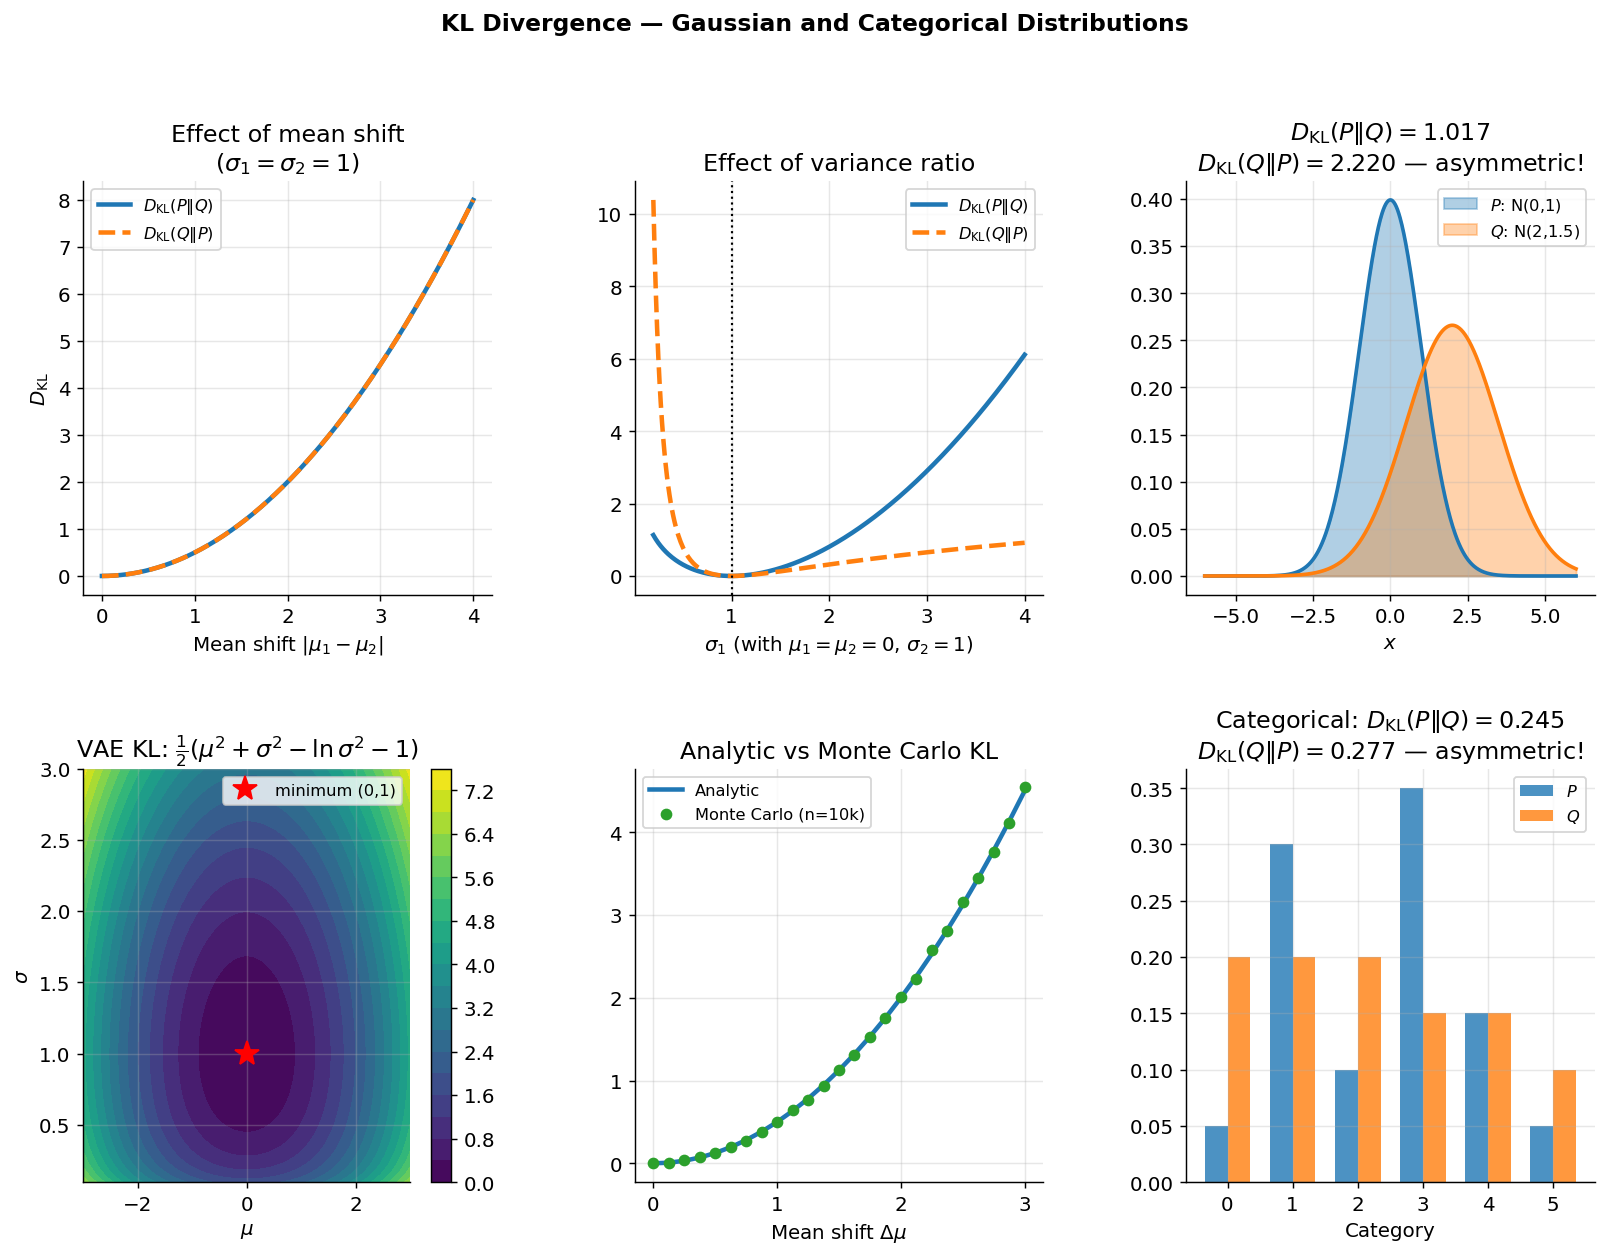


Closed-form vs Monte Carlo sanity check:
  Δμ=0.5: analytic=0.12500  MC=0.12517  err=0.00017
  Δμ=1.0: analytic=0.50000  MC=0.50689  err=0.00689
  Δμ=2.0: analytic=2.00000  MC=1.98673  err=0.01327


In [3]:
def kl_gaussian_closed(mu1, sig1, mu2, sig2):
    """KL(N(mu1,sig1^2) || N(mu2,sig2^2)) — analytic formula."""
    return (np.log(sig2/sig1)
            + (sig1**2 + (mu1-mu2)**2) / (2*sig2**2)
            - 0.5)

def kl_gaussian_numerical(mu1, sig1, mu2, sig2, n=5000):
    """Numerical estimate via Monte Carlo."""
    x  = np.random.normal(mu1, sig1, n)
    lp = norm.logpdf(x, mu1, sig1)
    lq = norm.logpdf(x, mu2, sig2)
    return float(np.mean(lp - lq))

# ── Panel A: effect of mean shift ─────────────────────────────────────────
fig = plt.figure(figsize=(15, 10))
gs  = gridspec.GridSpec(2, 3, hspace=0.42, wspace=0.35)

ax = fig.add_subplot(gs[0, 0])
x  = np.linspace(-6, 6, 600)
sig1, sig2 = 1.0, 1.0
mean_shifts = np.linspace(0, 4, 300)
kl_fw = [kl_gaussian_closed(0, sig1, d, sig2) for d in mean_shifts]
kl_rv = [kl_gaussian_closed(d, sig2, 0, sig1) for d in mean_shifts]
ax.plot(mean_shifts, kl_fw, lw=2.5, label=r'$D_{\mathrm{KL}}(P\|Q)$', color=COLORS[0])
ax.plot(mean_shifts, kl_rv, lw=2.5, label=r'$D_{\mathrm{KL}}(Q\|P)$', color=COLORS[1], ls='--')
ax.set_xlabel(r'Mean shift $|\mu_1 - \mu_2|$')
ax.set_ylabel(r'$D_{\mathrm{KL}}$')
ax.set_title('Effect of mean shift\n($\\sigma_1=\\sigma_2=1$)')
ax.legend(fontsize=9)

# ── Panel B: effect of variance ratio ────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
sig_ratios = np.linspace(0.2, 4.0, 300)
kl_fw2 = [kl_gaussian_closed(0, s, 0, 1.0) for s in sig_ratios]
kl_rv2 = [kl_gaussian_closed(0, 1.0, 0, s) for s in sig_ratios]
ax.plot(sig_ratios, kl_fw2, lw=2.5, label=r'$D_{\mathrm{KL}}(P\|Q)$', color=COLORS[0])
ax.plot(sig_ratios, kl_rv2, lw=2.5, label=r'$D_{\mathrm{KL}}(Q\|P)$', color=COLORS[1], ls='--')
ax.axvline(1, color='k', lw=1.2, ls=':')
ax.set_xlabel(r'$\sigma_1$ (with $\mu_1=\mu_2=0$, $\sigma_2=1$)')
ax.set_title('Effect of variance ratio')
ax.legend(fontsize=9)

# ── Panel C: illustrate forward vs reverse ───────────────────────────────
ax = fig.add_subplot(gs[0, 2])
P  = norm(0.0, 1.0)
Q  = norm(2.0, 1.5)
ax.fill_between(x, P.pdf(x), alpha=0.35, color=COLORS[0], label=f'$P$: N(0,1)')
ax.fill_between(x, Q.pdf(x), alpha=0.35, color=COLORS[1], label=f'$Q$: N(2,1.5)')
ax.plot(x, P.pdf(x), lw=2, color=COLORS[0])
ax.plot(x, Q.pdf(x), lw=2, color=COLORS[1])
kl_pq_val = kl_gaussian_closed(0, 1.0, 2.0, 1.5)
kl_qp_val = kl_gaussian_closed(2.0, 1.5, 0.0, 1.0)
ax.set_title(f'$D_{{\\mathrm{{KL}}}}(P\\|Q)={kl_pq_val:.3f}$\n'
             f'$D_{{\\mathrm{{KL}}}}(Q\\|P)={kl_qp_val:.3f}$ — asymmetric!')
ax.legend(fontsize=9); ax.set_xlabel('$x$')

# ── Panel D: VAE KL term — effect of mu and sigma ────────────────────────
ax = fig.add_subplot(gs[1, 0])
mu_vals  = np.linspace(-3, 3, 200)
sig_vals = np.linspace(0.1, 3, 200)
MU, SIG  = np.meshgrid(mu_vals, sig_vals)
KL_VAE   = 0.5 * (MU**2 + SIG**2 - np.log(SIG**2) - 1)
cf = ax.contourf(MU, SIG, KL_VAE, levels=20, cmap='viridis')
plt.colorbar(cf, ax=ax)
ax.set_xlabel(r'$\mu$'); ax.set_ylabel(r'$\sigma$')
ax.set_title(r'VAE KL: $\frac{1}{2}(\mu^2+\sigma^2-\ln\sigma^2-1)$')
ax.plot(0, 1, 'r*', ms=14, label='minimum (0,1)'); ax.legend(fontsize=9)

# ── Panel E: Numerical vs analytical KL, Gaussian ────────────────────────
ax = fig.add_subplot(gs[1, 1])
np.random.seed(42)
shifts_test = np.linspace(0, 3, 25)
kl_anal  = [kl_gaussian_closed(0, 1, d, 1) for d in shifts_test]
kl_mc    = [kl_gaussian_numerical(0, 1, d, 1, n=10000) for d in shifts_test]
ax.plot(shifts_test, kl_anal, lw=2.5, label='Analytic', color=COLORS[0])
ax.scatter(shifts_test, kl_mc, s=30, label='Monte Carlo (n=10k)', color=COLORS[2], zorder=5)
ax.set_xlabel(r'Mean shift $\Delta\mu$')
ax.set_title('Analytic vs Monte Carlo KL')
ax.legend(fontsize=9)

# ── Panel F: Gibbs inequality illustration ───────────────────────────────
ax = fig.add_subplot(gs[1, 2])
n_pts   = 6
cats    = np.arange(n_pts)
P_cat   = np.array([0.05, 0.30, 0.10, 0.35, 0.15, 0.05])
Q_cat   = np.array([0.20, 0.20, 0.20, 0.15, 0.15, 0.10])
width   = 0.35
ax.bar(cats - width/2, P_cat, width, label='$P$', color=COLORS[0], alpha=0.8)
ax.bar(cats + width/2, Q_cat, width, label='$Q$', color=COLORS[1], alpha=0.8)
ax.set_title(f'Categorical: $D_{{\\mathrm{{KL}}}}(P\\|Q)={kl_discrete(P_cat,Q_cat):.3f}$\n'
             f'$D_{{\\mathrm{{KL}}}}(Q\\|P)={kl_discrete(Q_cat,P_cat):.3f}$ — asymmetric!')
ax.set_xticks(cats); ax.set_xlabel('Category'); ax.legend(fontsize=9)

plt.suptitle('KL Divergence — Gaussian and Categorical Distributions',
             fontsize=13, fontweight='bold', y=1.01)
plt.show()

print('\nClosed-form vs Monte Carlo sanity check:')
for d in [0.5, 1.0, 2.0]:
    an = kl_gaussian_closed(0,1,d,1)
    mc = kl_gaussian_numerical(0,1,d,1,n=50000)
    print(f'  Δμ={d:.1f}: analytic={an:.5f}  MC={mc:.5f}  err={abs(an-mc):.5f}')


### 1.5  Forward vs reverse KL: mode-seeking vs mode-covering

Fitting a **unimodal Gaussian** $Q=\mathcal{N}(\mu,\sigma^2)$ to a **bimodal target** $P$
reveals the fundamental difference:

- **Forward KL** $D_{\mathrm{KL}}(P\|Q)$: zero-avoiding on $Q$ — produces a *mode-covering*
  solution that spreads probability mass to avoid placing zero mass where $P>0$.
- **Reverse KL** $D_{\mathrm{KL}}(Q\|P)$: zero-forcing on $Q$ — produces a *mode-seeking*
  solution that commits to one mode of $P$ and ignores the other.


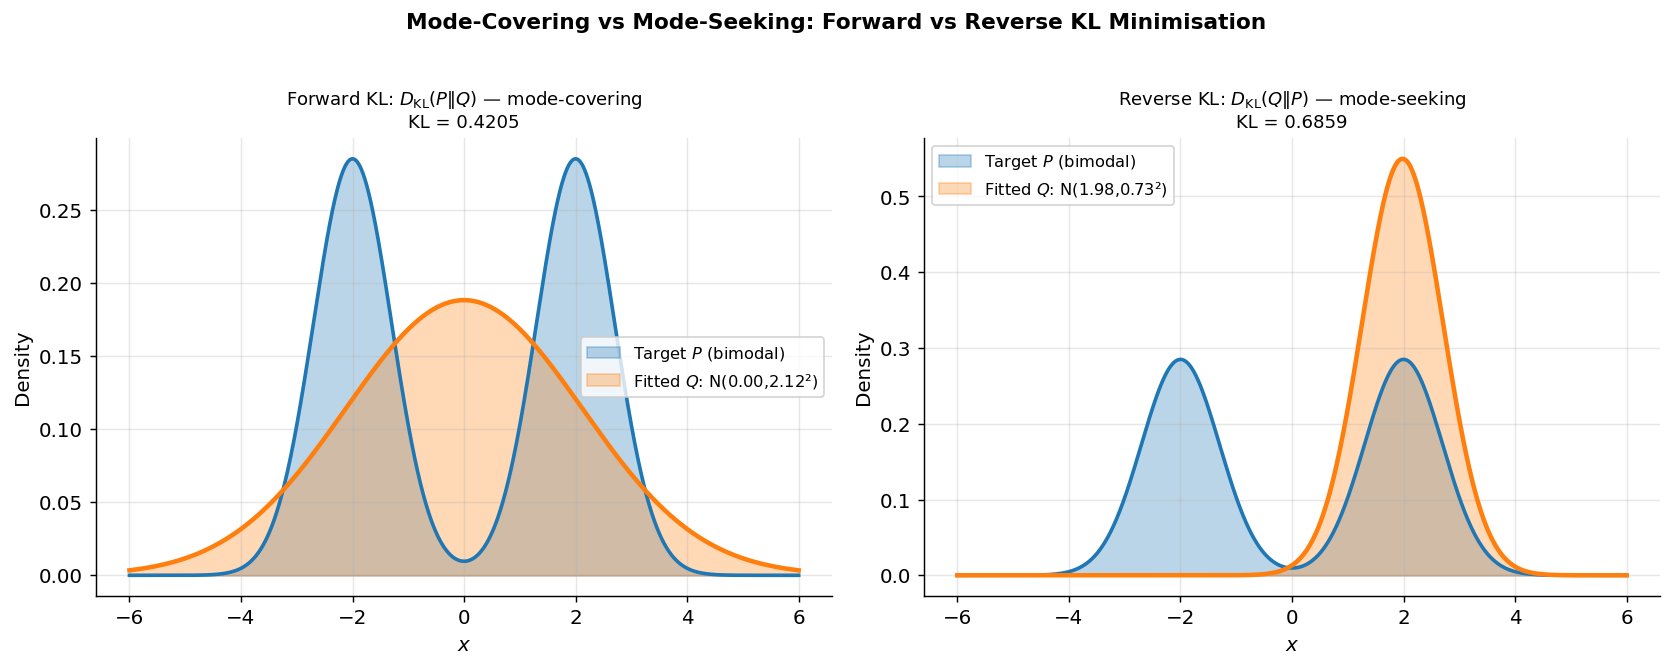

Forward KL fit:  mu=0.000,  sigma=2.119  (spreads across both modes)
Reverse KL fit:  mu=1.982,  sigma=0.726  (commits to one mode)


In [4]:
from scipy.optimize import minimize

def bimodal_pdf(x, w=0.5, mu1=-2.0, mu2=2.0, sig=0.7):
    return w*norm.pdf(x, mu1, sig) + (1-w)*norm.pdf(x, mu2, sig)

x_dense = np.linspace(-6, 6, 2000)
dx      = x_dense[1] - x_dense[0]
p_bim   = bimodal_pdf(x_dense)
p_bim  /= p_bim.sum() * dx      # normalise to density

def fit_gaussian_forward_kl(p_target, x, dx):
    """Fit N(mu, sig^2) by minimising KL(p_target || q_gaussian)."""
    def objective(params):
        mu, log_sig = params
        sig = np.exp(log_sig)
        q   = norm.pdf(x, mu, sig)
        q   = np.maximum(q, 1e-300)
        # KL(p||q) = integral p*log(p/q) dx ≈ sum(p * log(p/q)) * dx
        mask = p_target > 1e-300
        return float(np.sum(p_target[mask] * np.log(p_target[mask] / q[mask])) * dx)
    res = minimize(objective, [0.0, 0.0], method='Nelder-Mead',
                   options={'xatol':1e-6,'fatol':1e-8,'maxiter':5000})
    mu, sig = res.x[0], np.exp(res.x[1])
    return mu, sig, res.fun

def fit_gaussian_reverse_kl(p_target, x, dx):
    """Fit N(mu, sig^2) by minimising KL(q_gaussian || p_target)."""
    def objective(params):
        mu, log_sig = params
        sig = np.exp(log_sig)
        q   = norm.pdf(x, mu, sig)
        q   = np.maximum(q, 1e-300)
        pt  = np.maximum(p_target, 1e-300)
        return float(np.sum(q * np.log(q / pt)) * dx)
    res = minimize(objective, [2.0, np.log(0.5)], method='Nelder-Mead',
                   options={'xatol':1e-6,'fatol':1e-8,'maxiter':5000})
    mu, sig = res.x[0], np.exp(res.x[1])
    return mu, sig, res.fun

mu_fwd, sig_fwd, kl_fwd_val = fit_gaussian_forward_kl(p_bim, x_dense, dx)
mu_rev, sig_rev, kl_rev_val = fit_gaussian_reverse_kl(p_bim, x_dense, dx)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, mu, sig, kl_val, title, dirn in [
    (axes[0], mu_fwd, sig_fwd, kl_fwd_val,
     'Forward KL: $D_{\\mathrm{KL}}(P\\|Q)$ — mode-covering', 'forward'),
    (axes[1], mu_rev, sig_rev, kl_rev_val,
     'Reverse KL: $D_{\\mathrm{KL}}(Q\\|P)$ — mode-seeking', 'reverse'),
]:
    q_fit = norm.pdf(x_dense, mu, sig)
    ax.fill_between(x_dense, p_bim, alpha=0.3, color=COLORS[0], label='Target $P$ (bimodal)')
    ax.fill_between(x_dense, q_fit, alpha=0.3, color=COLORS[1], label=f'Fitted $Q$: N({mu:.2f},{sig:.2f}²)')
    ax.plot(x_dense, p_bim, lw=2, color=COLORS[0])
    ax.plot(x_dense, q_fit, lw=2.5, color=COLORS[1])
    ax.set_title(f'{title}\nKL = {kl_val:.4f}', fontsize=10)
    ax.set_xlabel('$x$'); ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.suptitle('Mode-Covering vs Mode-Seeking: Forward vs Reverse KL Minimisation',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

print(f'Forward KL fit:  mu={mu_fwd:.3f},  sigma={sig_fwd:.3f}  (spreads across both modes)')
print(f'Reverse KL fit:  mu={mu_rev:.3f},  sigma={sig_rev:.3f}  (commits to one mode)')


---
## 2  Energy-Based Models

An **energy-based model** assigns a scalar energy $E_\theta(x)\in\mathbb{R}$ to each
configuration $x$ and defines the Boltzmann distribution:

$$p_\theta(x) = \frac{e^{-E_\theta(x)}}{Z_\theta}, \qquad
Z_\theta = \sum_x e^{-E_\theta(x)}.$$

### 2.1  Log-likelihood gradient

Taking the log: $\log p_\theta(x) = -E_\theta(x) - \log Z_\theta$.

The **gradient of the log-likelihood** is:
$$\nabla_\theta\mathcal{L}(\theta)
= \mathbb{E}_{p_{\mathrm{data}}}[\nabla_\theta\log p_\theta(x)]
= -\mathbb{E}_{p_{\mathrm{data}}}[\nabla_\theta E_\theta] - \nabla_\theta\log Z_\theta.$$

**Gradient of the partition function** (key step):
$$\nabla_\theta\log Z_\theta
= \frac{\nabla_\theta Z_\theta}{Z_\theta}
= \frac{-\sum_x e^{-E_\theta(x)}\nabla_\theta E_\theta(x)}{Z_\theta}
= -\mathbb{E}_{p_\theta}[\nabla_\theta E_\theta(x)].$$

Combining:
$$\boxed{\nabla_\theta\mathcal{L}
= -\underbrace{\mathbb{E}_{p_{\mathrm{data}}}[\nabla_\theta E_\theta]}_{\text{positive phase}}
  + \underbrace{\mathbb{E}_{p_\theta}[\nabla_\theta E_\theta]}_{\text{negative phase}}.}$$

For **minimising** negative log-likelihood:
$$\nabla_\theta(-\mathcal{L})
= \underbrace{\langle\nabla_\theta E_\theta\rangle_{\mathrm{data}}}_{\text{lowers }E\text{ on data}}
  - \underbrace{\langle\nabla_\theta E_\theta\rangle_{\mathrm{model}}}_{\text{raises }E\text{ on model samples}}.$$


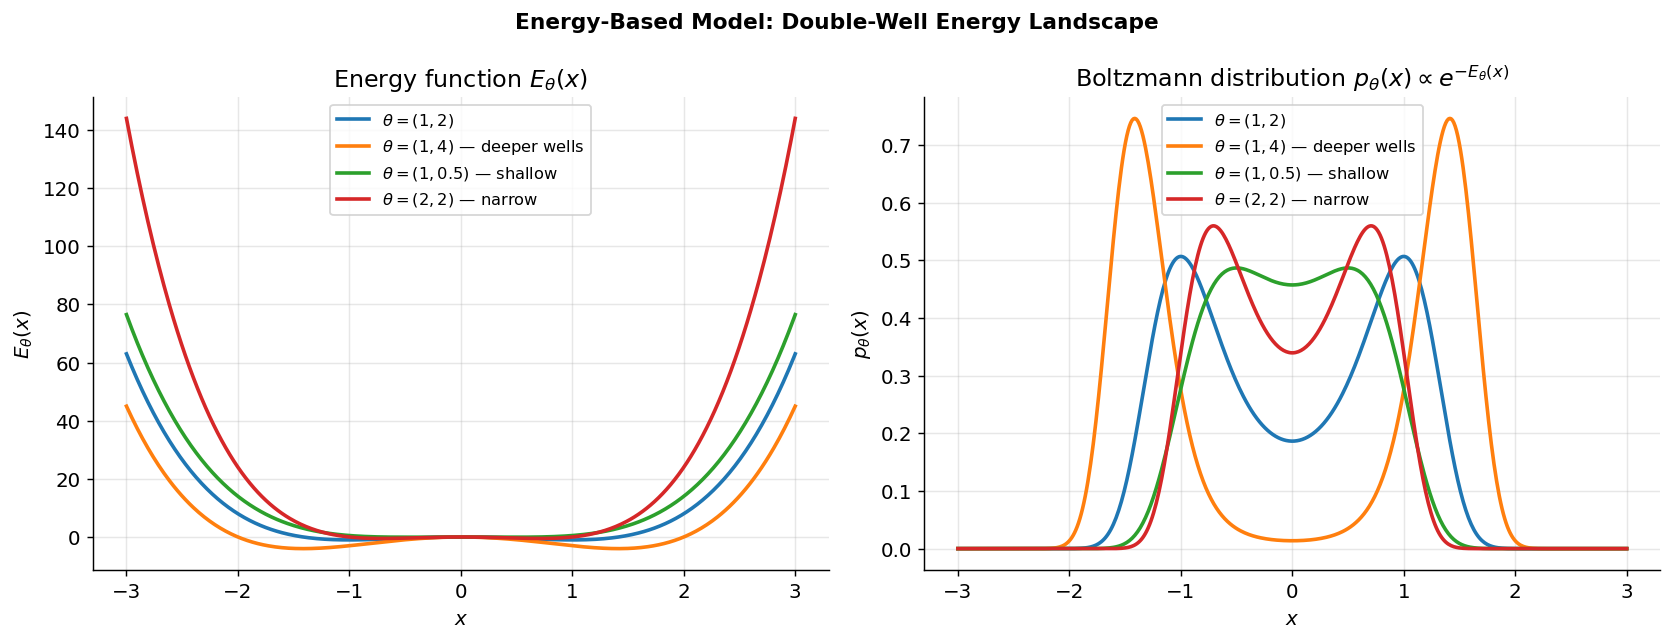

Gradient check (EBM, d/dθ₁):
  Positive phase ⟨∂E/∂θ₁⟩_data   = -1.83534
  Negative phase ⟨∂E/∂θ₁⟩_model  = -0.83275
  ∇_θ₁ L = -pos + neg             = 1.00260
  (Positive → decrease θ₁ → flatten wells; Negative → increase θ₁ → keep current shape)


In [5]:
# ── Visualise the energy landscape for a simple 1-D EBM ──────────────────
def energy(x, theta):
    """A simple double-well energy: E(x) = theta[0]*x^4 - theta[1]*x^2."""
    return theta[0] * x**4 - theta[1] * x**2

def boltzmann(x, theta, dx):
    e   = energy(x, theta)
    log_p = -e - np.log(np.sum(np.exp(-e)) * dx)
    return np.exp(log_p)

x     = np.linspace(-3, 3, 500)
dx    = x[1] - x[0]
theta_list = [(1.0, 2.0), (1.0, 4.0), (1.0, 0.5), (2.0, 2.0)]
labels     = [r'$\theta=(1,2)$', r'$\theta=(1,4)$ — deeper wells',
              r'$\theta=(1,0.5)$ — shallow', r'$\theta=(2,2)$ — narrow']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for th, lab in zip(theta_list, labels):
    e = energy(x, th)
    p = boltzmann(x, th, dx)
    axes[0].plot(x, e, lw=2, label=lab)
    axes[1].plot(x, p, lw=2, label=lab)

axes[0].set_title('Energy function $E_\\theta(x)$')
axes[0].set_xlabel('$x$'); axes[0].set_ylabel('$E_\\theta(x)$')
axes[0].legend(fontsize=9)

axes[1].set_title('Boltzmann distribution $p_\\theta(x) \\propto e^{-E_\\theta(x)}$')
axes[1].set_xlabel('$x$'); axes[1].set_ylabel('$p_\\theta(x)$')
axes[1].legend(fontsize=9)

plt.suptitle('Energy-Based Model: Double-Well Energy Landscape',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Verify gradient = positive phase - negative phase numerically ─────────
theta0 = np.array([1.0, 2.0])
p_data = boltzmann(x, [1.0, 4.0], dx)   # pretend data comes from deeper wells

# analytic gradient of E w.r.t theta[1] = -x^2
grad_E_wrt_th1 = -x**2

pos_phase = np.sum(p_data * grad_E_wrt_th1) * dx
neg_phase = np.sum(boltzmann(x, theta0, dx) * grad_E_wrt_th1) * dx
grad_L    = -pos_phase + neg_phase

print('Gradient check (EBM, d/dθ₁):')
print(f'  Positive phase ⟨∂E/∂θ₁⟩_data   = {pos_phase:.5f}')
print(f'  Negative phase ⟨∂E/∂θ₁⟩_model  = {neg_phase:.5f}')
print(f'  ∇_θ₁ L = -pos + neg             = {grad_L:.5f}')
print(f'  (Positive → decrease θ₁ → flatten wells; Negative → increase θ₁ → keep current shape)')


---
## 3  Restricted Boltzmann Machines

### 3.1  Architecture

A **Boltzmann machine** has visible units $v=(v_i)$ and hidden units $h=(h_j)$:
$$E_\theta(v,h) = -\sum_i a_i v_i - \sum_j b_j h_j - \sum_{ij}W_{ij}v_i h_j
                  - \sum_{i<k}U_{ik}v_iv_k - \sum_{j<\ell}V_{j\ell}h_jh_\ell.$$

In an **RBM** the within-layer connections are removed:
$$E_\theta(v,h) = -a^\top v - b^\top h - v^\top W h.$$

### 3.2  Conditional distributions (derivation)

The bipartite structure gives conditional independence.  For binary units:
$$p(h_j=1\mid v)
= \frac{e^{b_j+\sum_i W_{ij}v_i}}{1+e^{b_j+\sum_i W_{ij}v_i}}
= \sigma\!\left(b_j+\textstyle\sum_i W_{ij}v_i\right),$$
$$p(v_i=1\mid h) = \sigma\!\left(a_i+\textstyle\sum_j W_{ij}h_j\right).$$

### 3.3  Exact gradient

Since $\partial E/\partial W_{ij}=-v_ih_j$:
$$\frac{\partial\mathcal{L}}{\partial W_{ij}}
= \langle v_i h_j\rangle_{\mathrm{data}} - \langle v_i h_j\rangle_{\mathrm{model}}.$$


W scale=0.5: p(h=1|v) = 0.8176
W scale=1.0: p(h=1|v) = 0.9526
W scale=2.0: p(h=1|v) = 0.9975


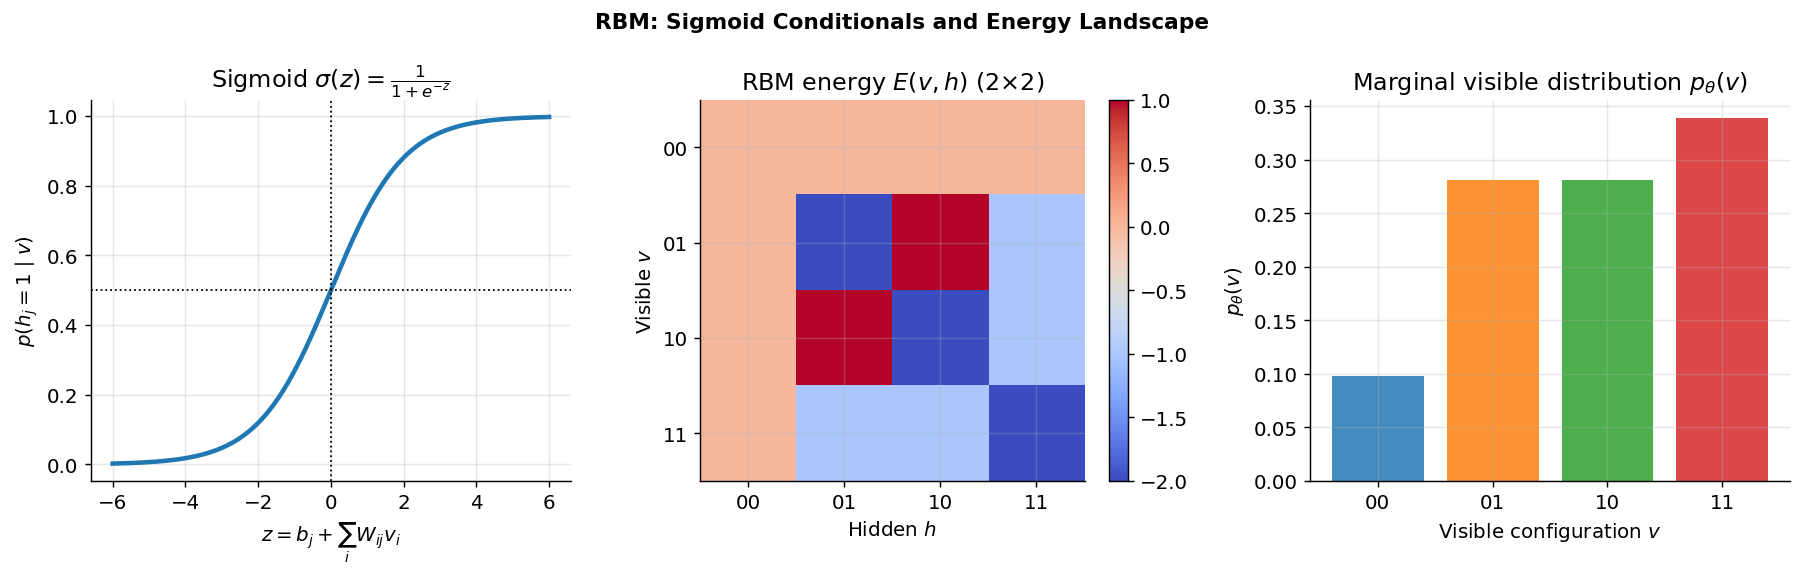

In [6]:
def sigmoid(x): return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

class RBM:
    def __init__(self, n_visible, n_hidden, seed=42):
        rng = np.random.default_rng(seed)
        self.W = rng.normal(0, 0.01, (n_visible, n_hidden))
        self.a = np.zeros(n_visible)   # visible biases
        self.b = np.zeros(n_hidden)    # hidden biases

    def h_given_v(self, v):
        """E[h | v] = sigmoid(b + W^T v)."""
        return sigmoid(self.b + v @ self.W)

    def v_given_h(self, h):
        """E[v | h] = sigmoid(a + W h)."""
        return sigmoid(self.a + h @ self.W.T)

    def sample_h(self, v):
        probs = self.h_given_v(v)
        return (np.random.rand(*probs.shape) < probs).astype(float), probs

    def sample_v(self, h):
        probs = self.v_given_h(h)
        return (np.random.rand(*probs.shape) < probs).astype(float), probs

    def cd1_update(self, v0_batch, lr=0.01):
        """One CD-1 step on a mini-batch. Returns (dW, da, db)."""
        # Positive phase
        h0_probs = self.h_given_v(v0_batch)
        h0_samples = (np.random.rand(*h0_probs.shape) < h0_probs).astype(float)
        # Negative phase (one Gibbs step)
        v1_probs  = self.v_given_h(h0_samples)
        v1        = (np.random.rand(*v1_probs.shape) < v1_probs).astype(float)
        h1_probs  = self.h_given_v(v1)
        # Gradient (mean over batch)
        B = v0_batch.shape[0]
        dW = (v0_batch.T @ h0_probs - v1.T @ h1_probs) / B
        da = (v0_batch - v1).mean(0)
        db = (h0_probs  - h1_probs).mean(0)
        # Update
        self.W += lr * dW
        self.a += lr * da
        self.b += lr * db
        # Reconstruction error
        return float(np.mean((v0_batch - v1_probs)**2))

# ── Demonstrate sigmoid conditionals ────────────────────────────────────
z_vals = np.linspace(-6, 6, 300)
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

axes[0].plot(z_vals, sigmoid(z_vals), lw=2.5, color=COLORS[0])
axes[0].axhline(0.5, color='k', lw=1, ls=':')
axes[0].axvline(0,   color='k', lw=1, ls=':')
axes[0].set_title(r'Sigmoid $\sigma(z)=\frac{1}{1+e^{-z}}$')
axes[0].set_xlabel('$z = b_j + \\sum_i W_{ij}v_i$')
axes[0].set_ylabel(r'$p(h_j=1\mid v)$')

# Show p(h|v) for different weight magnitudes
for scale, ls in [(0.5,'--'),(1.0,'-'),(2.0,':')]:
    v_ex = np.array([1,0,1,0,1], dtype=float)
    W_ex = scale * np.ones((5, 1))
    b_ex = 0.0
    z    = b_ex + v_ex @ W_ex
    print(f'W scale={scale}: p(h=1|v) = {sigmoid(z[0]):.4f}')

# Visualise energy surface for small RBM
rbm_viz = RBM(2, 2)
rbm_viz.W = np.array([[2.0, -1.0], [-1.0, 2.0]])
configs_v = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
configs_h = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)

energies = np.array([
    [-rbm_viz.a @ v - rbm_viz.b @ h - v @ rbm_viz.W @ h
     for h in configs_h]
    for v in configs_v])

im = axes[1].imshow(energies, cmap='coolwarm', aspect='auto')
plt.colorbar(im, ax=axes[1])
axes[1].set_xticks([0,1,2,3]); axes[1].set_yticks([0,1,2,3])
axes[1].set_xticklabels(['00','01','10','11'])
axes[1].set_yticklabels(['00','01','10','11'])
axes[1].set_xlabel('Hidden $h$'); axes[1].set_ylabel('Visible $v$')
axes[1].set_title('RBM energy $E(v,h)$ (2×2)')

# Marginal p(v)
log_Z  = np.log(np.sum(np.exp(-energies)))
pjoint = np.exp(-energies - log_Z)
p_vis  = pjoint.sum(axis=1)
axes[2].bar(['00','01','10','11'], p_vis, color=COLORS[:4], alpha=0.85)
axes[2].set_xlabel('Visible configuration $v$')
axes[2].set_ylabel('$p_\\theta(v)$')
axes[2].set_title('Marginal visible distribution $p_\\theta(v)$')

plt.suptitle('RBM: Sigmoid Conditionals and Energy Landscape',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


---
## 4  Contrastive Divergence

### 4.1  The bottleneck and the CD idea

The exact model expectation $\langle v_i h_j\rangle_{\mathrm{model}}$ requires running
Gibbs chains to equilibrium.  **Contrastive divergence** (Hinton 2002) replaces this
by *short chains initialised at data*:

$$v^{(0)}\!\sim p_{\mathrm{data}}
\;\to\; h^{(0)}\!\sim p(h|v^{(0)})
\;\to\; v^{(1)}\!\sim p(v|h^{(0)})
\;\to\; \cdots
\;\to\; v^{(k)},$$

yielding the CD-$k$ update:
$$\Delta W_{ij}^{\mathrm{CD-}k}
\propto \langle v_i h_j\rangle_{\mathrm{data}} - \langle v_i h_j\rangle_k.$$

### 4.2  Why "contrastive divergence"? — The objective

$$\mathrm{CD}_k(\theta) = D_{\mathrm{KL}}(p_0\|p_\theta) - D_{\mathrm{KL}}(p_k\|p_\theta),$$

where $p_0=p_{\mathrm{data}}$ and $p_k=p_0 T_\theta^k$ ($T_\theta$ = Gibbs kernel).

### 4.3  Gradient derivation

**First term** (exact ML gradient, $p_0$ fixed):
$$\nabla_\theta D_{\mathrm{KL}}(p_0\|p_\theta)
= \langle\nabla_\theta E_\theta\rangle_{p_0}
  - \langle\nabla_\theta E_\theta\rangle_{p_\theta}.$$

**Second term** (CD approximation: neglect $\nabla_\theta p_k\approx 0$):
$$\nabla_\theta D_{\mathrm{KL}}(p_k\|p_\theta)
\approx \langle\nabla_\theta E_\theta\rangle_{p_k}
         - \langle\nabla_\theta E_\theta\rangle_{p_\theta}.$$

**Cancellation of model expectations:**
$$\nabla_\theta\mathrm{CD}_k
\approx \Bigl[\langle\nabla_\theta E_\theta\rangle_{p_0}
               - \langle\nabla_\theta E_\theta\rangle_{p_\theta}\Bigr]
         - \Bigl[\langle\nabla_\theta E_\theta\rangle_{p_k}
               - \langle\nabla_\theta E_\theta\rangle_{p_\theta}\Bigr]
= \boxed{\langle\nabla_\theta E_\theta\rangle_{p_0}
         - \langle\nabla_\theta E_\theta\rangle_{p_k}.}$$

The intractable partition-function gradient cancels.

### 4.4  Bias of CD

The neglected implicit term is
$$\sum_x(\nabla_\theta p_k(x))\log\frac{p_k(x)}{p_\theta(x)},$$
which vanishes as $k\to\infty$ (when $p_k\to p_\theta$).  For finite $k$, CD-$k$ is a
**biased** but **computationally efficient** approximation.


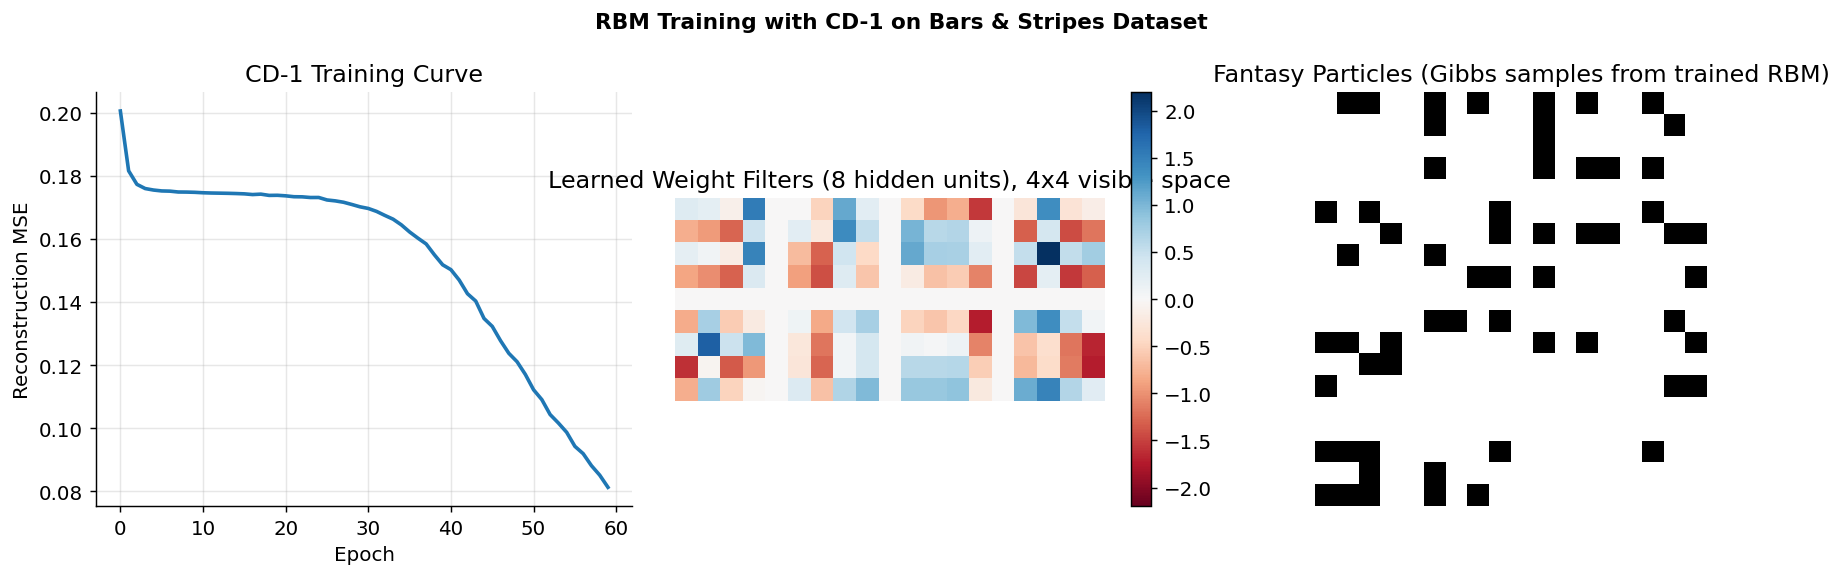

Final reconstruction MSE: 0.08130
Weight matrix shape: (16, 8)


In [7]:
# ── Full RBM training on a synthetic dataset using CD-1 ───────────────────
np.random.seed(0)

# Synthetic data: bars and stripes on a 4×4 grid (16 visible units)
def make_bars_stripes(n=500, size=4, noise=0.05):
    samples = []
    for _ in range(n):
        if np.random.rand() < 0.5:
            pat = np.zeros((size, size))
            row = np.random.randint(size)
            pat[row, :] = 1.0           # horizontal bar
        else:
            pat = np.zeros((size, size))
            col = np.random.randint(size)
            pat[:, col] = 1.0           # vertical stripe
        pat = np.clip(pat + noise * np.random.randn(size, size), 0, 1)
        samples.append(pat.flatten())
    return np.array(samples)

data = make_bars_stripes(n=2000, size=4)

# Train an RBM with 16 visible, 8 hidden units
rbm = RBM(n_visible=16, n_hidden=8, seed=7)
EPOCHS     = 60
BATCH_SIZE = 64
LR         = 0.05
errors     = []

for ep in range(EPOCHS):
    perm = np.random.permutation(len(data))
    ep_err = []
    for start in range(0, len(data), BATCH_SIZE):
        batch = data[perm[start:start+BATCH_SIZE]]
        err   = rbm.cd1_update(batch, lr=LR)
        ep_err.append(err)
    errors.append(np.mean(ep_err))

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# Panel 1: training curve
axes[0].plot(errors, lw=2, color=COLORS[0])
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Reconstruction MSE')
axes[0].set_title('CD-1 Training Curve')

# Panel 2: learned weight filters
W_vis = rbm.W.T.reshape(8, 4, 4)
grid  = np.zeros((2*4+1, 4*4+3))
for k in range(8):
    r, c = divmod(k, 4)
    grid[r*5:r*5+4, c*5:c*5+4] = W_vis[k]
im = axes[1].imshow(grid, cmap='RdBu', vmin=-np.abs(grid).max(), vmax=np.abs(grid).max())
plt.colorbar(im, ax=axes[1])
axes[1].set_title('Learned Weight Filters (8 hidden units), 4x4 visible space')
axes[1].axis('off')

# Panel 3: fantasy particles (Gibbs sampling from trained RBM)
v_fantasy = np.random.rand(16, 16) > 0.5   # random init (shape: n_fantasy × n_vis)
v_fantasy = v_fantasy.astype(float)
for _ in range(1000):                        # burn-in
    h_f, _ = rbm.sample_h(v_fantasy)
    v_fantasy, _ = rbm.sample_v(h_f)

grid_f = np.zeros((4*4+3, 4*4+3))
for k in range(16):
    r, c = divmod(k, 4)
    grid_f[r*5:r*5+4, c*5:c*5+4] = v_fantasy[k].reshape(4,4)
axes[2].imshow(grid_f, cmap='Greys', vmin=0, vmax=1)
axes[2].set_title('Fantasy Particles (Gibbs samples from trained RBM)')
axes[2].axis('off')

plt.suptitle('RBM Training with CD-1 on Bars & Stripes Dataset',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()
print(f'Final reconstruction MSE: {errors[-1]:.5f}')
print(f'Weight matrix shape: {rbm.W.shape}')


---
## 5  Persistent CD (PCD) and Stochastic Maximum Likelihood (SML)

### 5.1  Persistent CD

CD-$k$ reinitialises chains at data every step, limiting Markov chain mixing.
**PCD** (Tieleman 2008) maintains *persistent fantasy particles* $\{v^{(n)}\}$:

1. Run one Gibbs step from each fantasy particle: $v^{(n)}\to v^{(n)}{}'$.
2. Update: $\Delta W_{ij} = \eta\bigl(\langle v_i h_j\rangle_{\mathrm{data}} - \langle v_i h_j\rangle_{\mathrm{fantasy}}\bigr)$.
3. Keep the updated particles for the next step.

Because particles are never reinitialised, they gradually explore the full model
distribution, giving a less biased estimate of the negative phase.

### 5.2  Comparison

| | CD-$k$ | PCD |
|---|---|---|
| Chain initialisation | data | persistent fantasy |
| Bias | larger | smaller |
| Mixing | local (near data) | global |
| Cost per step | $k$ Gibbs steps | 1 Gibbs step |


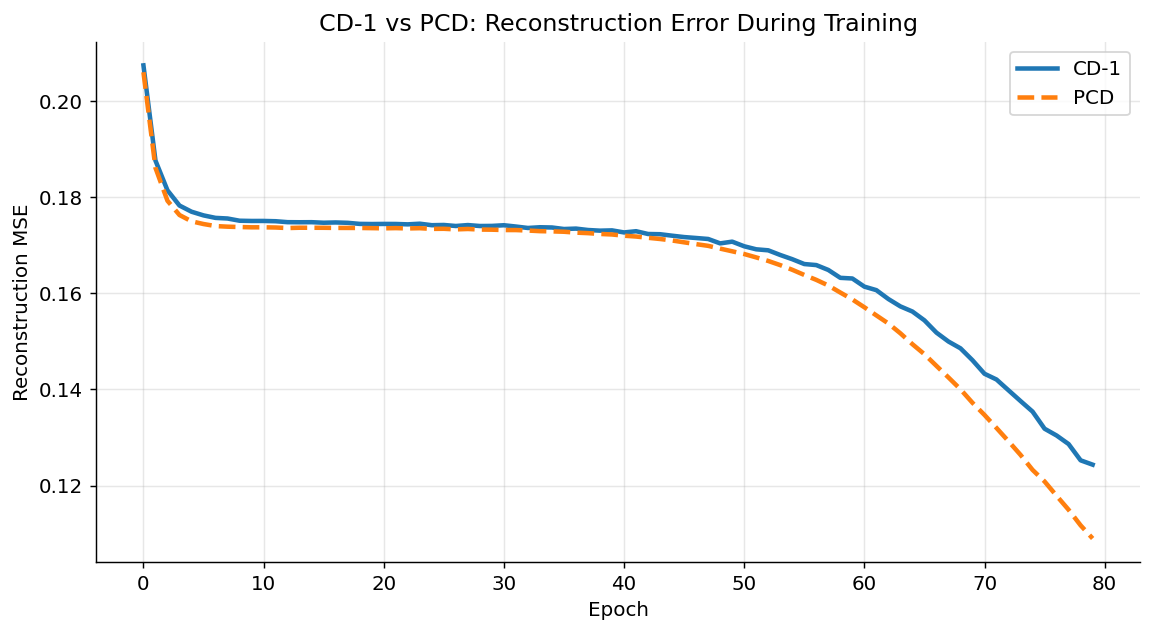

CD-1  final MSE: 0.12435
PCD   final MSE: 0.10899


In [8]:
class RBM_PCD(RBM):
    """RBM trained with Persistent Contrastive Divergence."""
    def __init__(self, n_visible, n_hidden, n_fantasy=100, seed=42):
        super().__init__(n_visible, n_hidden, seed)
        rng = np.random.default_rng(seed)
        # Initialise fantasy particles randomly
        self.fantasy = (rng.random((n_fantasy, n_visible)) > 0.5).astype(float)

    def pcd_update(self, v0_batch, lr=0.01):
        """One PCD step."""
        B = v0_batch.shape[0]
        # Positive phase
        h0_probs = self.h_given_v(v0_batch)
        # Negative phase: one step from persistent chain
        h_f, _   = self.sample_h(self.fantasy)
        v_f, _   = self.sample_v(h_f)
        hf_probs = self.h_given_v(v_f)
        # Update weights
        dW = (v0_batch.T @ h0_probs / B) - (v_f.T @ hf_probs / self.fantasy.shape[0])
        da = v0_batch.mean(0) - v_f.mean(0)
        db = h0_probs.mean(0) - hf_probs.mean(0)
        self.W += lr * dW
        self.a += lr * da
        self.b += lr * db
        # Update fantasy particles
        self.fantasy = v_f
        return float(np.mean((v0_batch - self.v_given_h(h0_probs))**2))

# ── Compare CD-1 vs PCD on bars & stripes ─────────────────────────────────
np.random.seed(1)
rbm_cd  = RBM(n_visible=16, n_hidden=8, seed=7)
rbm_pcd = RBM_PCD(n_visible=16, n_hidden=8, n_fantasy=200, seed=7)

errors_cd  = []
errors_pcd = []
EPOCHS     = 80
LR         = 0.03

for ep in range(EPOCHS):
    perm = np.random.permutation(len(data))
    e_cd = e_pcd = 0.0; n_batches = 0
    for start in range(0, len(data), 64):
        batch = data[perm[start:start+64]]
        e_cd  += rbm_cd.cd1_update(batch, lr=LR)
        e_pcd += rbm_pcd.pcd_update(batch, lr=LR)
        n_batches += 1
    errors_cd.append(e_cd / n_batches)
    errors_pcd.append(e_pcd / n_batches)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(errors_cd,  lw=2.5, label='CD-1',          color=COLORS[0])
ax.plot(errors_pcd, lw=2.5, label='PCD',  ls='--', color=COLORS[1])
ax.set_xlabel('Epoch'); ax.set_ylabel('Reconstruction MSE')
ax.set_title('CD-1 vs PCD: Reconstruction Error During Training')
ax.legend()
plt.tight_layout(); plt.show()

print(f'CD-1  final MSE: {errors_cd[-1]:.5f}')
print(f'PCD   final MSE: {errors_pcd[-1]:.5f}')


---
## 6  CD as a Contrast of KL Divergences

The contrastive-divergence objective is:
$$\mathrm{CD}_k(\theta) = D_{\mathrm{KL}}(p_0\|p_\theta) - D_{\mathrm{KL}}(p_k\|p_\theta).$$

Key properties:
- $\mathrm{CD}_0 = 0$ (trivially, since $p_0 = p_0$).
- As $k\to\infty$: $p_k\to p_\theta$, so $\mathrm{CD}_k \to D_{\mathrm{KL}}(p_0\|p_\theta)$ = exact ML.
- For finite $k$: $\mathrm{CD}_k$ measures how much the data distribution diverges
  from the model, compared with how much the $k$-step reconstruction distribution
  diverges from it.

The learning rule adjusts $\theta$ to **lower** $\mathrm{CD}_k$, which means
simultaneously making the model closer to the data and further from the
$k$-step reconstructions.


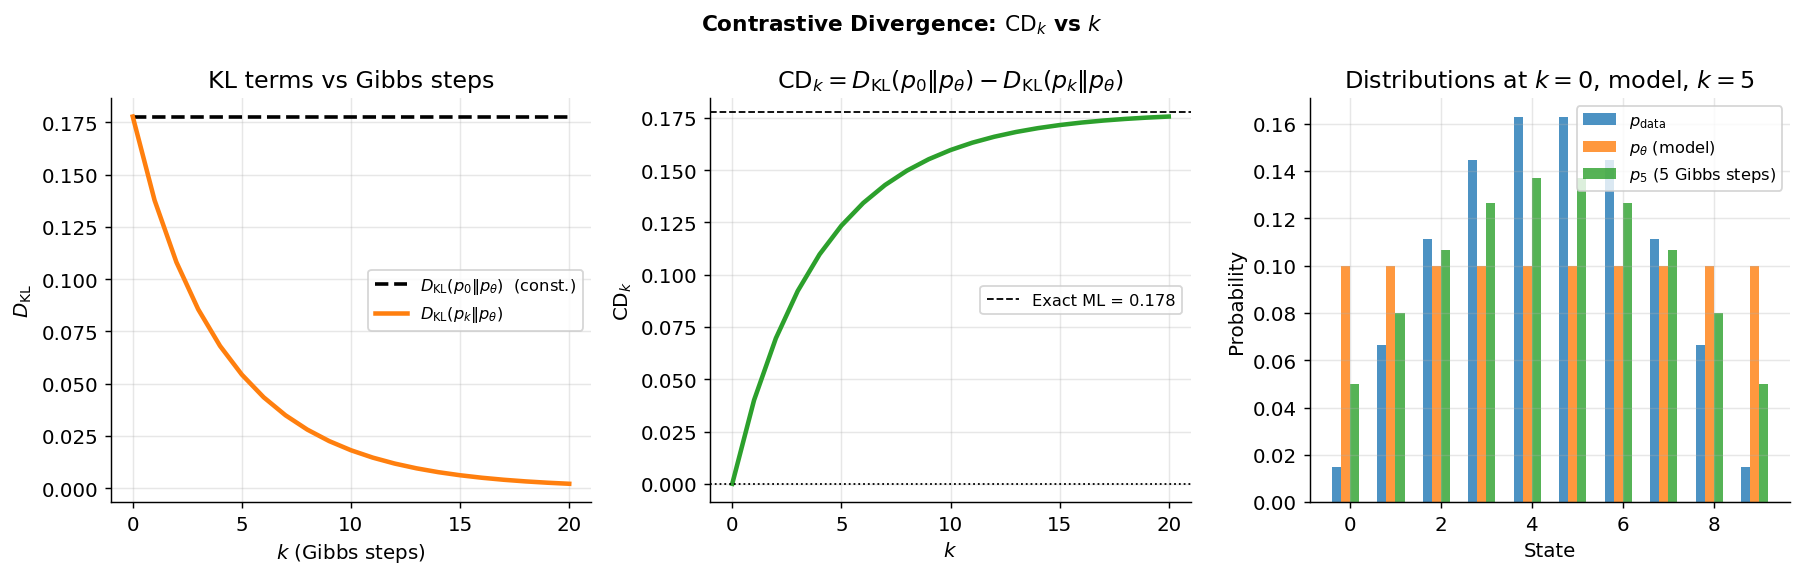

In [9]:
# ── Visualise how CD_k changes as k increases for a 1-D discrete model ────
np.random.seed(2)
N_STATES = 10
x_states = np.arange(N_STATES)

# True data distribution and initial model
p_data_disc  = np.abs(np.sin(np.linspace(0, np.pi, N_STATES)) + 0.1)
p_data_disc /= p_data_disc.sum()

# Model: uniform initially, then shaped by energy
theta_model  = np.zeros(N_STATES)              # log-unnormalised
p_model      = np.exp(theta_model)
p_model     /= p_model.sum()

def gibbs_step_discrete(p_current, p_stationary):
    """Simple random-walk Gibbs step toward stationary distribution."""
    # Move to a random neighbour with probability proportional to p_stationary
    new_p = 0.9 * p_current + 0.1 * p_stationary
    return new_p / new_p.sum()

# Track KL(p_data||p_model), KL(p_k||p_model) and CD_k for k = 0..20
k_vals = np.arange(0, 21)
kl_data_model = kl_discrete(p_data_disc, p_model)
kl_k_model_list = []
cd_k_list = []

p_k = p_data_disc.copy()
for k in k_vals:
    kl_km = kl_discrete(p_k, p_model)
    kl_k_model_list.append(kl_km)
    cd_k_list.append(kl_data_model - kl_km)
    p_k = gibbs_step_discrete(p_k, p_model)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

axes[0].plot(k_vals, [kl_data_model]*len(k_vals), 'k--', lw=2,
             label=r'$D_{\mathrm{KL}}(p_0\|p_\theta)$  (const.)')
axes[0].plot(k_vals, kl_k_model_list, lw=2.5, color=COLORS[1],
             label=r'$D_{\mathrm{KL}}(p_k\|p_\theta)$')
axes[0].set_xlabel('$k$ (Gibbs steps)'); axes[0].set_ylabel(r'$D_{\mathrm{KL}}$')
axes[0].set_title('KL terms vs Gibbs steps')
axes[0].legend(fontsize=9)

axes[1].plot(k_vals, cd_k_list, lw=2.5, color=COLORS[2])
axes[1].axhline(0, color='k', lw=1, ls=':')
axes[1].axhline(kl_data_model, color='k', lw=1, ls='--',
                label=f'Exact ML = {kl_data_model:.3f}')
axes[1].set_xlabel('$k$'); axes[1].set_ylabel(r'$\mathrm{CD}_k$')
axes[1].set_title(r'$\mathrm{CD}_k = D_{\mathrm{KL}}(p_0\|p_\theta) - D_{\mathrm{KL}}(p_k\|p_\theta)$')
axes[1].legend(fontsize=9)

# Show p_data, p_model, p_k at k=1,5,10
axes[2].bar(x_states - 0.3, p_data_disc, 0.2, label='$p_{\\mathrm{data}}$',
            color=COLORS[0], alpha=0.8)
axes[2].bar(x_states - 0.1, p_model, 0.2, label='$p_\\theta$ (model)',
            color=COLORS[1], alpha=0.8)
p_k_show = p_data_disc.copy()
for _ in range(5):
    p_k_show = gibbs_step_discrete(p_k_show, p_model)
axes[2].bar(x_states + 0.1, p_k_show, 0.2, label='$p_5$ (5 Gibbs steps)',
            color=COLORS[2], alpha=0.8)
axes[2].set_xlabel('State'); axes[2].set_ylabel('Probability')
axes[2].set_title('Distributions at $k=0$, model, $k=5$')
axes[2].legend(fontsize=9)

plt.suptitle(r'Contrastive Divergence: $\mathrm{CD}_k$ vs $k$',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


---
## 7  Quantum Boltzmann Machines

### 7.1  Setup

A **quantum Boltzmann machine** (QBM) replaces the classical energy by a
Hamiltonian $H_\theta$ acting on a Hilbert space $\mathcal{H}$.  The thermal
(**Gibbs**) state at inverse temperature $\beta$ is:

$$\rho_\theta = \frac{e^{-\beta H_\theta}}{Z_\theta}, \qquad
Z_\theta = \operatorname{Tr}(e^{-\beta H_\theta}).$$

Visible measurement probabilities:
$$p_\theta(v) = \operatorname{Tr}[\Pi_v\,\rho_\theta],
\qquad \Pi_v = |v\rangle\langle v|.$$

### 7.2  Gradient: commuting case

For $H_\theta = \sum_a\theta_a O_a$ with all $[O_a, O_{a'}]=0$:
$$\partial_{\theta_a}\log Z_\theta = -\beta\operatorname{Tr}(\rho_\theta O_a)
= -\beta\langle O_a\rangle_{\rho_\theta},$$
giving the classical BM structure:
$$\nabla_{\theta_a}(-\mathcal{L})
= \beta(\langle O_a\rangle_{\mathrm{data}} - \langle O_a\rangle_{\rho_\theta}).$$

### 7.3  Gradient: non-commuting case (Duhamel formula)

When $[H_\theta,\partial_{\theta_a}H_\theta]\ne 0$:
$$\partial_{\theta_a}e^{-\beta H_\theta}
= -\int_0^\beta e^{-(\beta-\tau)H_\theta}O_a\,e^{-\tau H_\theta}\,d\tau.$$

This introduces the **symmetrised imaginary-time correlator**:
$$\widetilde{\langle O_a\rangle}_{\rho_\theta}
= \frac{1}{\beta}\int_0^\beta
  \operatorname{Tr}[\rho_\theta^{1-\tau/\beta}\,O_a\,\rho_\theta^{\tau/\beta}]\,d\tau,$$
so that $\partial_{\theta_a}\log Z_\theta = -\beta\,\widetilde{\langle O_a\rangle}_{\rho_\theta}$.

### 7.4  Quantum CD objective

Replacing $D_{\mathrm{KL}}$ with the **quantum relative entropy**
$S(\rho\|\sigma) = \operatorname{Tr}[\rho(\log\rho-\log\sigma)]$:
$$\mathrm{QCD}_k(\theta) = S(\rho_0\|\rho_\theta) - S(\rho_k\|\rho_\theta).$$


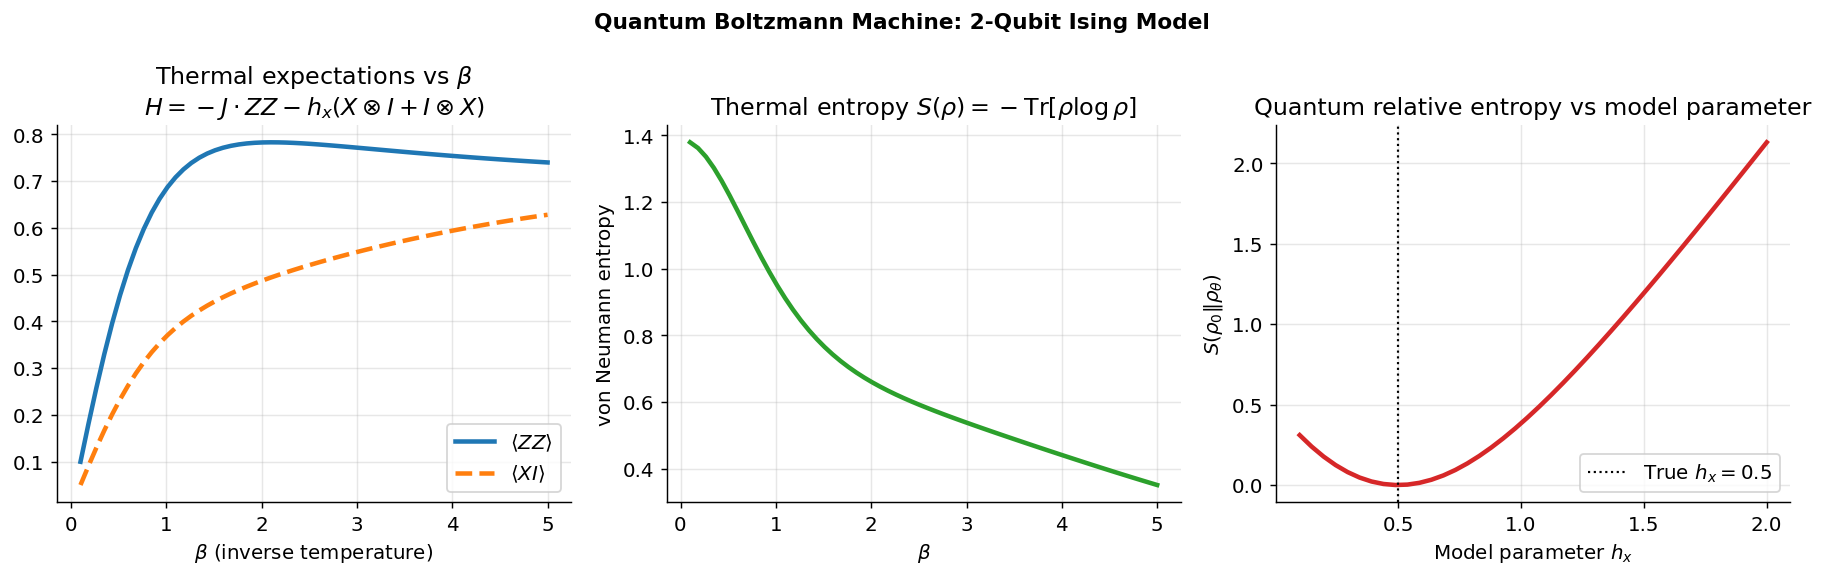

In [10]:
import numpy.linalg as la

# ── Small QBM: 2-qubit Ising Hamiltonian ─────────────────────────────────
# H = -J*ZZ - h_x*(X⊗I + I⊗X)
# Pauli matrices
I = np.eye(2, dtype=complex)
X = np.array([[0,1],[1,0]], dtype=complex)
Z = np.array([[1,0],[0,-1]], dtype=complex)

def kron2(A, B): return np.kron(A, B)

ZZ = kron2(Z, Z)
XI = kron2(X, I)
IX = kron2(I, X)

def hamiltonian(J, hx):
    return -J * ZZ - hx * (XI + IX)

def gibbs_state(H, beta):
    """rho = exp(-beta H) / Tr(exp(-beta H))."""
    evals, evecs = la.eigh(H)
    exp_vals     = np.exp(-beta * evals)
    rho          = evecs @ np.diag(exp_vals) @ evecs.conj().T
    return rho / rho.trace().real

def quantum_kl(rho, sigma, eps=1e-12):
    """S(rho || sigma) = Tr[rho (log rho - log sigma)]."""
    def matrix_log(M):
        evals, evecs = la.eigh(M)
        evals = np.maximum(evals.real, eps)
        return evecs @ np.diag(np.log(evals)) @ evecs.conj().T
    log_rho   = matrix_log(rho)
    log_sigma = matrix_log(sigma)
    return np.real(np.trace(rho @ (log_rho - log_sigma)))

def expect(O, rho):
    """Tr[O rho] (real part)."""
    return np.real(np.trace(O @ rho))

# ── Sweep beta: thermal state properties ─────────────────────────────────
J_val  = 1.0
hx_val = 0.5
H0     = hamiltonian(J_val, hx_val)
betas  = np.linspace(0.1, 5.0, 60)

exp_ZZ_list  = []
exp_XI_list  = []
entropy_list = []

for b in betas:
    rho = gibbs_state(H0, b)
    exp_ZZ_list.append(expect(ZZ, rho))
    exp_XI_list.append(expect(XI, rho))
    evals = la.eigvalsh(rho)
    evals = np.maximum(evals, 1e-15)
    entropy_list.append(-np.sum(evals * np.log(evals)))

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

axes[0].plot(betas, exp_ZZ_list, lw=2.5, label=r'$\langle ZZ\rangle$', color=COLORS[0])
axes[0].plot(betas, exp_XI_list, lw=2.5, label=r'$\langle XI\rangle$',  color=COLORS[1], ls='--')
axes[0].set_xlabel(r'$\beta$ (inverse temperature)')
axes[0].set_title('Thermal expectations vs $\\beta$\n'
                  r'$H=-J\cdot ZZ - h_x(X\otimes I + I\otimes X)$')
axes[0].legend()

axes[1].plot(betas, entropy_list, lw=2.5, color=COLORS[2])
axes[1].set_xlabel(r'$\beta$'); axes[1].set_ylabel('von Neumann entropy')
axes[1].set_title('Thermal entropy $S(\\rho) = -\\operatorname{Tr}[\\rho\\log\\rho]$')

# ── Quantum relative entropy S(rho0 || rho_theta) vs theta ───────────────
# Fix rho0 = Gibbs state at beta=2, J=1, hx=0.5
rho0 = gibbs_state(hamiltonian(1.0, 0.5), beta=2.0)
hx_range = np.linspace(0.1, 2.0, 40)
qkl_list = []
for hx in hx_range:
    rho_th = gibbs_state(hamiltonian(1.0, hx), beta=2.0)
    qkl_list.append(quantum_kl(rho0, rho_th))

axes[2].plot(hx_range, qkl_list, lw=2.5, color=COLORS[3])
axes[2].axvline(0.5, color='k', lw=1.2, ls=':', label='True $h_x=0.5$')
axes[2].set_xlabel(r'Model parameter $h_x$')
axes[2].set_ylabel(r'$S(\rho_0\|\rho_\theta)$')
axes[2].set_title('Quantum relative entropy vs model parameter')
axes[2].legend()

plt.suptitle('Quantum Boltzmann Machine: 2-Qubit Ising Model',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


In [ ]:
# ── Imaginary-time correlator vs commutator ───────────────────────────────
# Compare symmetrised imaginary-time expectation with ordinary expectation
# For the commuting case (hx=0) they should agree;
# for non-commuting case (hx>0) they differ.

def imag_time_correlator(O, H, beta, n_tau=200):
    """
    Numerically compute the symmetrised imaginary-time correlator:
       (1/beta) * int_0^beta Tr[rho^{1-tau/beta} O rho^{tau/beta}] d_tau
    """
    evals, evecs = la.eigh(H)
    U   = evecs
    tau_vals = np.linspace(0, beta, n_tau)
    integrand = []
    for tau in tau_vals:
        exp1 = np.exp(-(beta - tau) * evals)
        exp2 = np.exp(-tau * evals)
        rho1 = U @ np.diag(exp1) @ U.conj().T
        rho2 = U @ np.diag(exp2) @ U.conj().T
        Z    = np.sum(np.exp(-beta * evals))
        integrand.append(np.real(np.trace(rho1 @ O @ rho2)) / Z)
    return float(np.trapezoid(integrand, tau_vals) if hasattr(np, "trapezoid") else np.trapz(integrand, tau_vals)) / beta

beta_fixed = 2.0
hx_range2  = np.linspace(0, 1.5, 30)
ord_exp    = []   # ordinary <ZZ>
sym_exp    = []   # symmetrised imaginary-time <ZZ>

for hx in hx_range2:
    H_test  = hamiltonian(1.0, hx)
    rho_t   = gibbs_state(H_test, beta_fixed)
    ord_exp.append(expect(ZZ, rho_t))
    sym_exp.append(imag_time_correlator(ZZ, H_test, beta_fixed))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(hx_range2, ord_exp, lw=2.5, label=r'Ordinary: $\langle ZZ\rangle_{\rho_\theta}$',
        color=COLORS[0])
ax.plot(hx_range2, sym_exp, lw=2.5, ls='--',
        label=r'Imaginary-time: $\widetilde{\langle ZZ\rangle}_{\rho_\theta}$',
        color=COLORS[1])
ax.axvline(0, color='gray', lw=1.2, ls=':')
ax.annotate('Commuting (hx=0): equal', xy=(0.02, sym_exp[0]),
            xytext=(0.3, sym_exp[0]-0.1),
            arrowprops=dict(arrowstyle='->', color='k'), fontsize=9)
ax.set_xlabel(r'$h_x$ (non-commuting transverse field)')
ax.set_ylabel(r'Expectation value of $ZZ$')
ax.set_title('Ordinary vs Symmetrised Imaginary-Time Correlator\n'
             r'$H = -ZZ - h_x(XI+IX)$,  $\beta=2$')
ax.legend()
plt.tight_layout(); plt.show()

print('At hx=0 (commuting):')
print(f'  Ordinary:  {ord_exp[0]:.5f}')
print(f'  Imag-time: {sym_exp[0]:.5f}')
print(f'  Diff:      {abs(ord_exp[0]-sym_exp[0]):.2e}  (should be ~0)')
print(f'\nAt hx=1.0 (non-commuting):')
idx = np.argmin(np.abs(np.array(hx_range2) - 1.0))
print(f'  Ordinary:  {ord_exp[idx]:.5f}')
print(f'  Imag-time: {sym_exp[idx]:.5f}')
print(f'  Diff:      {abs(ord_exp[idx]-sym_exp[idx]):.5f}  (non-zero!)')


---
## 8  Summary

### Classical CD

For a classical EBM $p_\theta(x)=e^{-E_\theta(x)}/Z_\theta$, ML gives:
$$\nabla_\theta(-\mathcal{L})
= \langle\nabla_\theta E_\theta\rangle_{\mathrm{data}}
  - \langle\nabla_\theta E_\theta\rangle_{\mathrm{model}}.$$

CD-$k$ replaces the intractable model expectation with a $k$-step Gibbs approximation:
$$\nabla_\theta\mathrm{CD}_k
\approx \langle\nabla_\theta E_\theta\rangle_{p_0}
         - \langle\nabla_\theta E_\theta\rangle_{p_k}.$$

### Why the name?

$$\boxed{\mathrm{CD}_k = D_{\mathrm{KL}}(p_{\mathrm{data}}\|p_\theta) - D_{\mathrm{KL}}(p_k\|p_\theta).}$$

| Term | Meaning |
|------|---------|
| **Contrastive** | contrast data statistics with $k$-step reconstruction statistics |
| **Divergence** | the contrast is expressed via KL divergences |

### Quantum extension

| Case | Gradient formula |
|------|-----------------|
| Commuting $H$ | $\nabla_{\theta_a}(-\mathcal{L}) = \beta(\langle O_a\rangle_{\mathrm{data}} - \langle O_a\rangle_{\rho_\theta})$ |
| Non-commuting $H$ | $\partial_{\theta_a}\log Z_\theta = -\beta\,\widetilde{\langle O_a\rangle}_{\rho_\theta}$ (imaginary-time integral) |
| Quantum CD | $\Delta\theta_a \propto \langle O_a\rangle_{\mathrm{data}} - \langle O_a\rangle_{\rho_k}$ |
| Quantum CD objective | $\mathrm{QCD}_k = S(\rho_0\|\rho_\theta) - S(\rho_k\|\rho_\theta)$ |


In [ ]:
# ── Final summary figure: the CD story in one panel ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: CD_k value as k increases, for different model qualities
np.random.seed(5)
N = 8
p_d = np.abs(np.random.dirichlet(np.ones(N) * 2))

for gap, col, lab in [(0.5, COLORS[0], 'Poor model'),
                      (0.2, COLORS[1], 'Medium model'),
                      (0.05, COLORS[2], 'Good model')]:
    eps = np.abs(np.random.dirichlet(np.ones(N))) * gap
    p_m = p_d + eps; p_m /= p_m.sum()
    kl0 = kl_discrete(p_d, p_m)
    pk  = p_d.copy()
    cd_ks = []
    for _ in range(20):
        cd_ks.append(kl0 - kl_discrete(pk, p_m))
        pk = 0.8*pk + 0.2*p_m; pk /= pk.sum()
    axes[0].plot(cd_ks, lw=2.5, label=f'{lab}  (KL={kl0:.3f})',
                 color=col)

axes[0].set_xlabel('$k$ (Gibbs steps)')
axes[0].set_ylabel(r'$\mathrm{CD}_k$')
axes[0].set_title(r'$\mathrm{CD}_k$ converges to exact KL as $k\to\infty$')
axes[0].legend(fontsize=9)

# Right: Cartoon of energy landscape — CD lowers data energy, raises recon energy
x_c = np.linspace(-3, 3, 300)
E0  = x_c**4 - 3*x_c**2            # initial energy
E1  = x_c**4 - 3*x_c**2 - 0.5*np.exp(-(x_c+1.5)**2/0.3) + 0.5*np.exp(-(x_c+0.3)**2/0.3)

axes[1].plot(x_c, E0, lw=2, ls='--', color='gray', label='Before CD step')
axes[1].plot(x_c, E1, lw=2.5, color=COLORS[0], label='After CD step')
axes[1].axvline(-1.5, color=COLORS[1], lw=1.5, ls=':',  label='Data point $x_{\\mathrm{data}}$')
axes[1].axvline(-0.3, color=COLORS[2], lw=1.5, ls='-.', label='Reconstruction $x_{\\mathrm{recon}}$')
axes[1].annotate('$E$ lowered\nhere', xy=(-1.5, E1[np.argmin(np.abs(x_c+1.5))]),
                 xytext=(-2.3, 2), arrowprops=dict(arrowstyle='->', color=COLORS[1]),
                 fontsize=9, color=COLORS[1])
axes[1].annotate('$E$ raised\nhere', xy=(-0.3, E1[np.argmin(np.abs(x_c+0.3))]),
                 xytext=(0.5, 1.5), arrowprops=dict(arrowstyle='->', color=COLORS[2]),
                 fontsize=9, color=COLORS[2])
axes[1].set_xlabel('$x$'); axes[1].set_ylabel('$E_\\theta(x)$')
axes[1].set_title('CD reshapes the energy landscape')
axes[1].legend(fontsize=9)

plt.suptitle('Contrastive Divergence — Summary',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print('\n=== Contrastive Divergence: Take-Home Summary ===')
print('CD_k = KL(p_data || p_model) - KL(p_k || p_model)')
print()
print('• "Contrastive": compares data and k-step reconstruction statistics.')
print('• "Divergence":  comparison expressed through KL divergences.')
print('• For k=0: CD_0 = 0  (trivial).')
print('• As k→∞: CD_k → KL(p_data||p_model)  (exact maximum likelihood).')
print('• CD-k update: ΔW ∝ ⟨vh⟩_data − ⟨vh⟩_k  (no partition function needed).')
